In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests


In [6]:
def sample_image(image, factor):
    """
    Downsamples the image by the given factor.
    Args:
        image (numpy array): Original image.
        factor (int): Factor by which to downsample.
    Returns:
        numpy array: Downsampled image.
    """
    height, width = image.shape[:2]
    sampled_image = cv2.resize(image, (width // factor, height // factor), interpolation=cv2.INTER_NEAREST)
    return sampled_image

In [7]:
def quantize_image(image, levels):
    """
    Reduces the number of grayscale levels in the image.
    Args:
    image (numpy array): Original image.
    levels (int): Number of grayscale levels.
    Returns:
    numpy array: Quantized image.
    """
    quantized_image = np.floor(image / (256 // levels)) * (256 //
    levels)
    quantized_image = quantized_image.astype(np.uint8)
    return quantized_image

In [17]:
np.floor(np.array([10, 12, 20, 40, 69, 67, 80, 90, 130, 140, 150]) / (256 // 4)) * (256 // 4)

array([  0.,   0.,   0.,   0.,  64.,  64.,  64.,  64., 128., 128., 128.])

In [27]:

def plot_images(original, sampled, quantized, factor=None):
    """
    Plots the original, sampled, and quantized images side by side.
    Args:
    original (numpy array): Original image.
    sampled (numpy array): Sampled image.
    quantized (numpy array): Quantized image.
    """
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(original, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')
    plt.subplot(1, 3, 2)
    plt.imshow(sampled, cmap='gray')
    plt.title('Sampled Image')
    plt.axis('off')
    plt.subplot(1, 3, 3)
    plt.imshow(quantized, cmap='gray')
    plt.title('Quantized Image')
    plt.axis('off')

    if factor:
        plt.suptitle(f'Factor = {factor}', fontsize=16)

    plt.show()

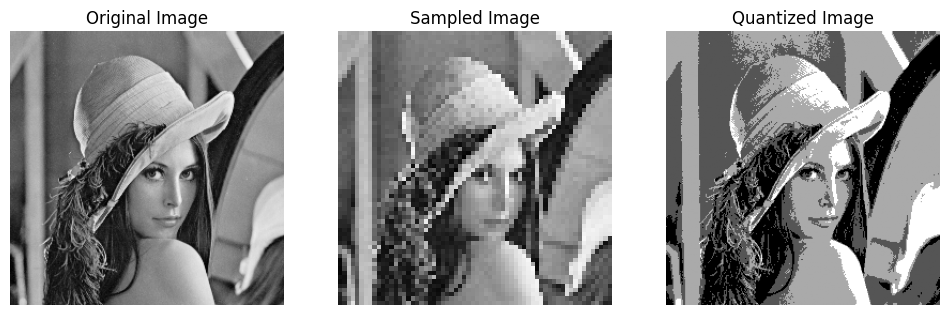

In [28]:
# Parameters
sampling_factor=4
quantization_levels=4

# Use the raw GitHub URL
url = "https://raw.githubusercontent.com/ashish-kmr/BTP_inpaint/master/lena_gray_256.tif"
resp = requests.get(url)
original_image = cv2.imdecode(np.frombuffer(resp.content, np.uint8), cv2.IMREAD_GRAYSCALE)

if original_image is None:
    print(f"Error: Unable to load image from URL")

# Sample and quantize
sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)

# Plot results
plot_images(original_image, sampled_image, quantized_image)


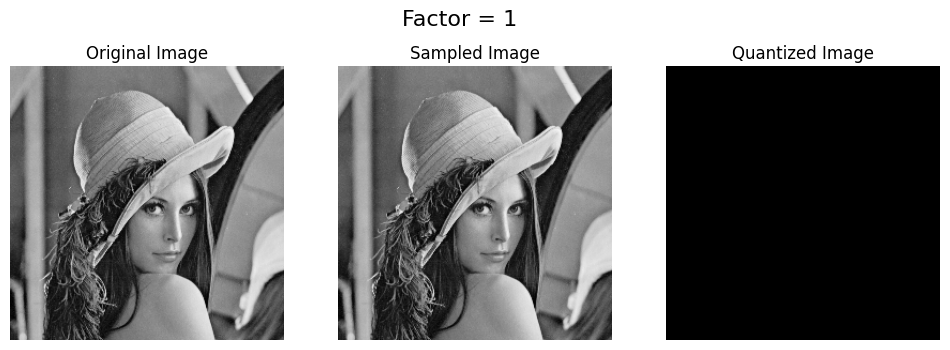

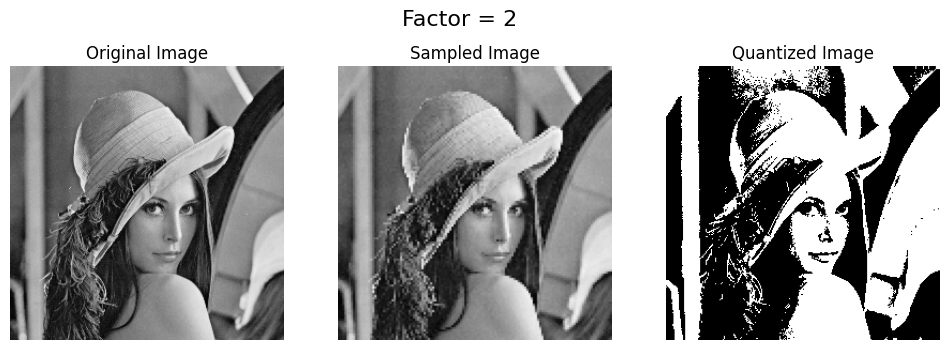

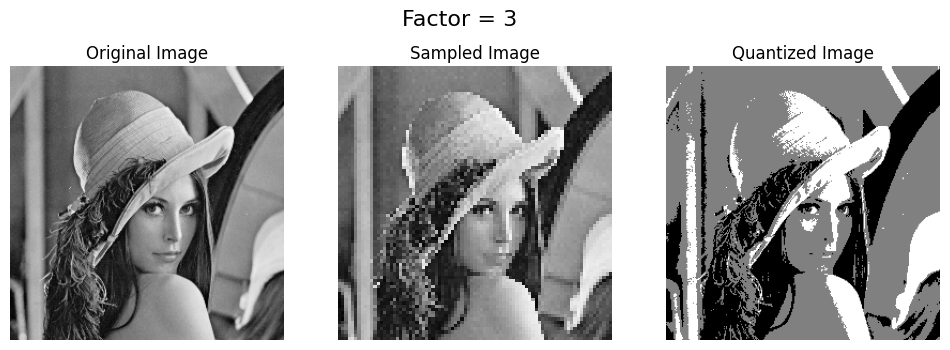

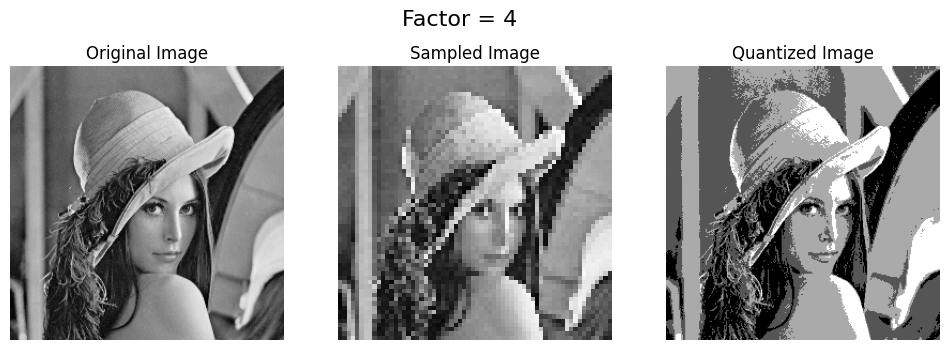

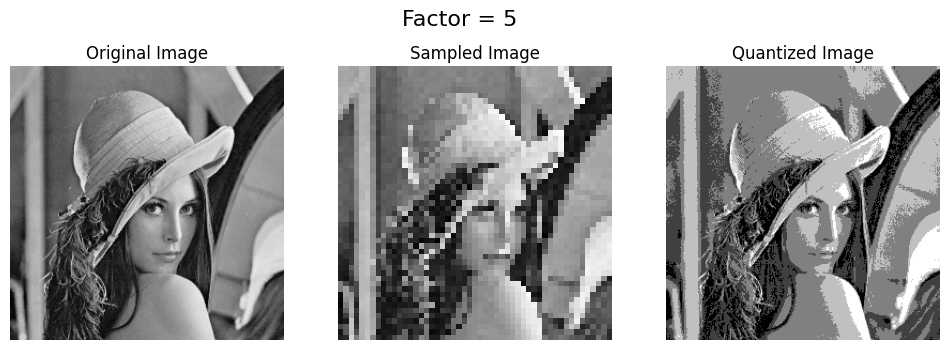

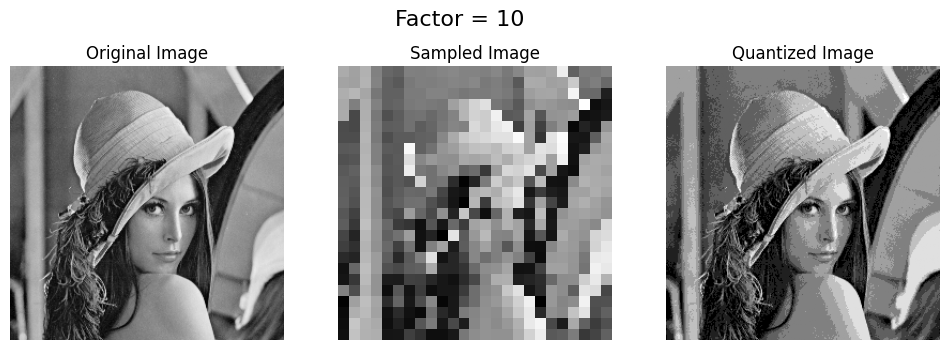

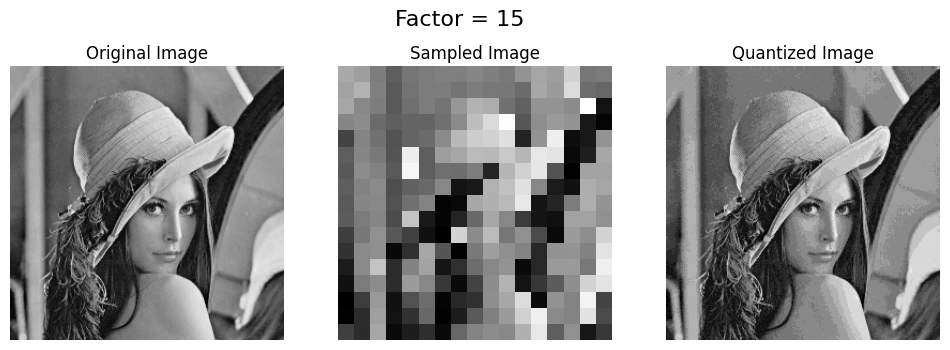

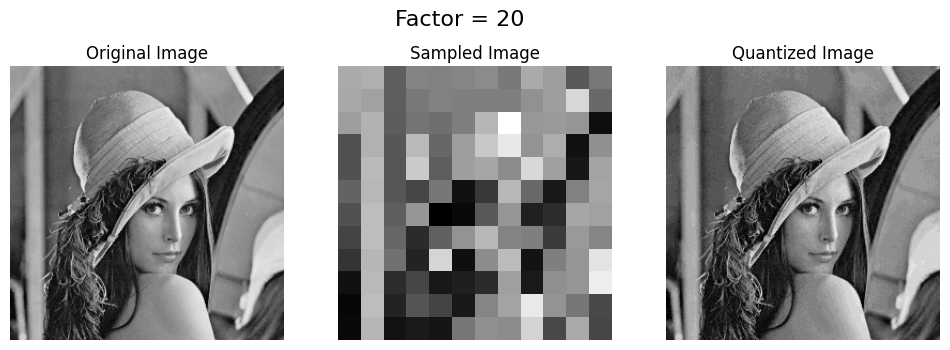

In [30]:
for i in [1, 2, 3, 4, 5, 10, 15, 20]:
  # Parameters
  sampling_factor=i
  quantization_levels=i

  # original_image = cv2.imdecode(np.frombuffer(resp.content, np.uint8), cv2.IMREAD_GRAYSCALE)

  # Sample and quantize
  sampled_image = sample_image(original_image, sampling_factor)
  quantized_image = quantize_image(original_image, quantization_levels)

  # Plot results
  plot_images(original_image, sampled_image, quantized_image, factor=i)



In [31]:
#  Task#2: Read two images, convert them into arrays, and perform the following operations on them.
# 1.	Subtract two images and display the result.
# 2.	Add one image with a constant value of 175 and display it.
# 3.	Apply the set difference operation on two Gray-Scale images.
# 4.	Apply the symmetric difference operation on two Gray-Scale images.
# 5.	Apply Intersection operations on two Gray-Scale images.


In [52]:
def get_img(url):
  resp = requests.get(url)
  return cv2.imdecode(np.frombuffer(resp.content, np.uint8), cv2.IMREAD_GRAYSCALE)
img1 = get_img("https://raw.githubusercontent.com/ashish-kmr/BTP_inpaint/master/jetplane.tif")
img2 = get_img("https://raw.githubusercontent.com/ashish-kmr/BTP_inpaint/master/cameraman.tif")

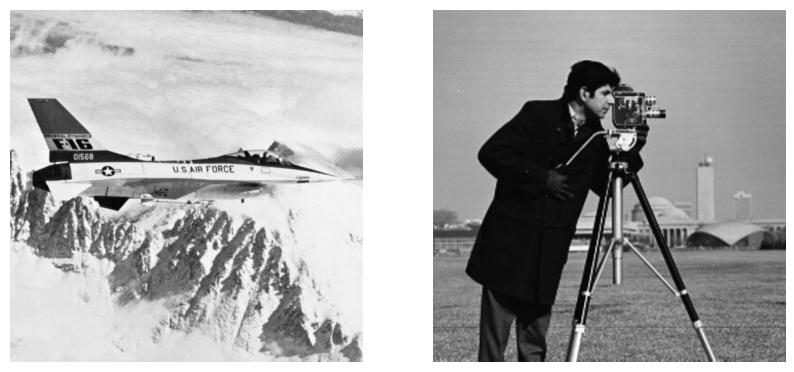

In [56]:
plt.figure(figsize=(10,5)); plt.subplot(1,2,1); plt.imshow(img1, cmap='gray'); plt.axis('off'); plt.subplot(1,2,2); plt.imshow(img2, cmap='gray'); plt.axis('off'); plt.show()


array([[ 37,  28,  18, ...,  13,  12, 251],
       [ 35,  38,  35, ...,  26,   4, 243],
       [ 35,  40,  38, ...,  38,   4, 244],
       ...,
       [ 94,  89,  82, ...,  84,  95, 101],
       [ 96,  88,  82, ...,  71,  75,  80],
       [ 92,  88,  85, ...,  63,  63,  38]], dtype=uint8)
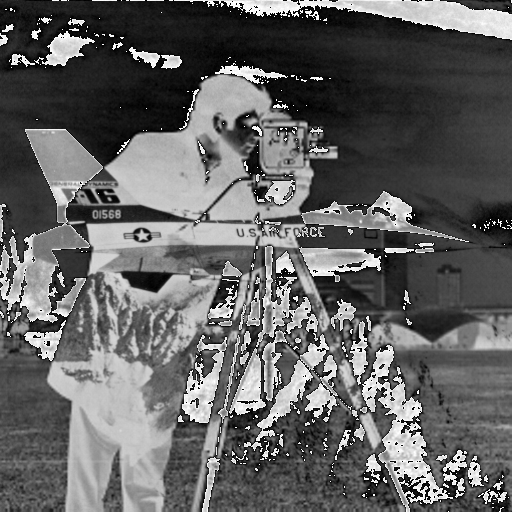

In [57]:
# 1.	Subtract two images and display the result.
img1 - img2

array([[112, 104,  97, ...,  84,  83,  66],
       [110, 114, 113, ...,  97,  75,  58],
       [112, 116, 113, ..., 109,  75,  59],
       ...,
       [134, 131, 127, ..., 124, 127, 131],
       [136, 130, 127, ..., 111, 107, 110],
       [132, 130, 130, ..., 103,  95,  68]], dtype=uint8)
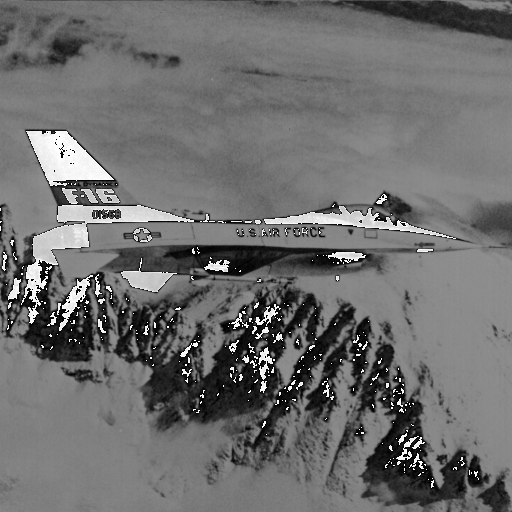

In [65]:
# 2.	Add one image with a constant value of 175 and display it.
img1 + 175

array([[ 37,  28,  18, ...,  13,  12,   0],
       [ 35,  38,  35, ...,  26,   4,   0],
       [ 35,  40,  38, ...,  38,   4,   0],
       ...,
       [ 94,  89,  82, ...,  84,  95, 101],
       [ 96,  88,  82, ...,  71,  75,  80],
       [ 92,  88,  85, ...,  63,  63,  38]], dtype=uint8)
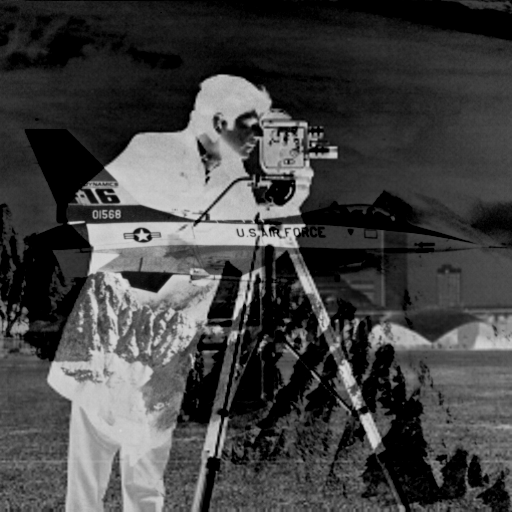

In [66]:
# 3.	Apply the set difference operation on two Gray-Scale images.
difference = cv2.subtract(img1, img2)
difference

array([[ 37,  28,  18, ...,  13,  12,   5],
       [ 35,  38,  35, ...,  26,   4,  13],
       [ 35,  40,  38, ...,  38,   4,  12],
       ...,
       [ 94,  89,  82, ...,  84,  95, 101],
       [ 96,  88,  82, ...,  71,  75,  80],
       [ 92,  88,  85, ...,  63,  63,  38]], dtype=uint8)
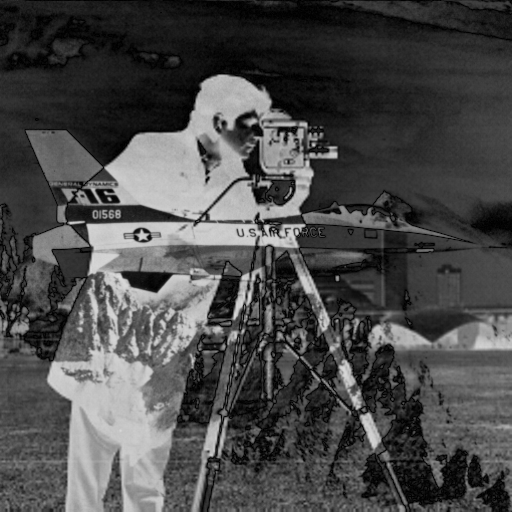

In [68]:
# 4.	Apply the symmetric difference operation on two Gray-Scale images.
cv2.absdiff(img1, img2)

array([[156, 157, 160, ..., 152, 152, 147],
       [156, 157, 159, ..., 152, 152, 139],
       [158, 157, 156, ..., 152, 152, 140],
       ...,
       [121, 123, 126, ..., 121, 113, 111],
       [121, 123, 126, ..., 121, 113, 111],
       [121, 123, 126, ..., 121, 113, 111]], dtype=uint8)
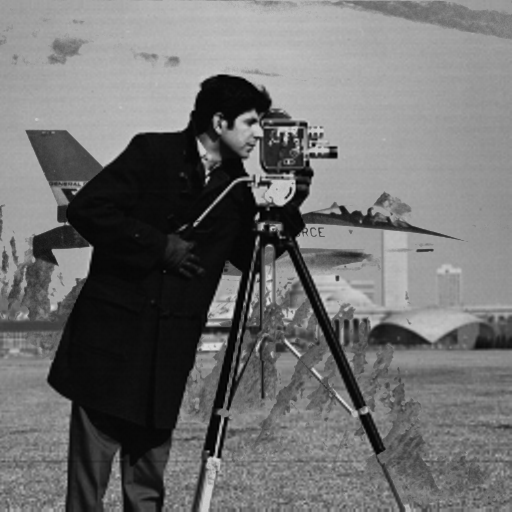

In [69]:
# 5.	Apply Intersection operations on two Gray-Scale images.
np.minimum(img1, img2)

array([[193, 185, 178, ..., 165, 164, 152],
       [191, 195, 194, ..., 178, 156, 152],
       [193, 197, 194, ..., 190, 156, 152],
       ...,
       [215, 212, 208, ..., 205, 208, 212],
       [217, 211, 208, ..., 192, 188, 191],
       [213, 211, 211, ..., 184, 176, 149]], dtype=uint8)
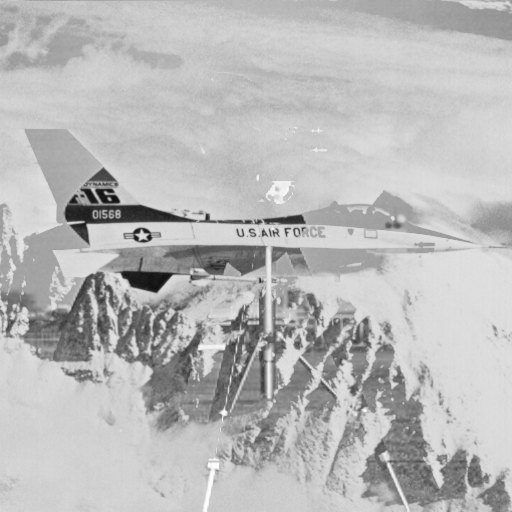

In [70]:
# Extra.	Apply union operations on two Gray-Scale images.
np.maximum(img1, img2)

Sam Altman left the chat